In [1]:
import pandas as pd
import numpy as np
import datetime as dt

df_clean = pd.read_csv(
    "../data/processed/cleaned_online_retail.csv",
    parse_dates=["InvoiceDate"]
)

df_clean.head()

/Users/garv/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [2]:

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [3]:
last_purchase = df.groupby("Customer ID")["InvoiceDate"].max().reset_index()

last_purchase.head()

,Customer ID,InvoiceDate
0,12346.0,2011-01-18 10:01:00
1,12347.0,2011-12-07 15:52:00
2,12348.0,2011-09-25 13:13:00
3,12349.0,2011-11-21 09:51:00
4,12350.0,2011-02-02 16:01:00


In [9]:
reference_date = df["InvoiceDate"].max() + dt.timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [10]:
last_purchase["DaysSinceLastPurchase"] = (
    reference_date - last_purchase["InvoiceDate"]
).dt.days

last_purchase.head()

,Customer ID,InvoiceDate,DaysSinceLastPurchase
0,12346.0,2011-01-18 10:01:00,326
1,12347.0,2011-12-07 15:52:00,2
2,12348.0,2011-09-25 13:13:00,75
3,12349.0,2011-11-21 09:51:00,19
4,12350.0,2011-02-02 16:01:00,310


In [11]:
def classify_customer(days):

    if days <= 30:
        return "Active"

    elif days <= 90:
        return "At Risk"

    else:
        return "Churned"


last_purchase["Status"] = last_purchase[
    "DaysSinceLastPurchase"
].apply(classify_customer)

last_purchase.head()

,Customer ID,InvoiceDate,DaysSinceLastPurchase,Status
0,12346.0,2011-01-18 10:01:00,326,Churned
1,12347.0,2011-12-07 15:52:00,2,Active
2,12348.0,2011-09-25 13:13:00,75,At Risk
3,12349.0,2011-11-21 09:51:00,19,Active
4,12350.0,2011-02-02 16:01:00,310,Churned


In [12]:
status_counts = last_purchase["Status"].value_counts()

status_counts

Status
Churned    2991
Active     1649
At Risk    1241
Name: count, dtype: int64

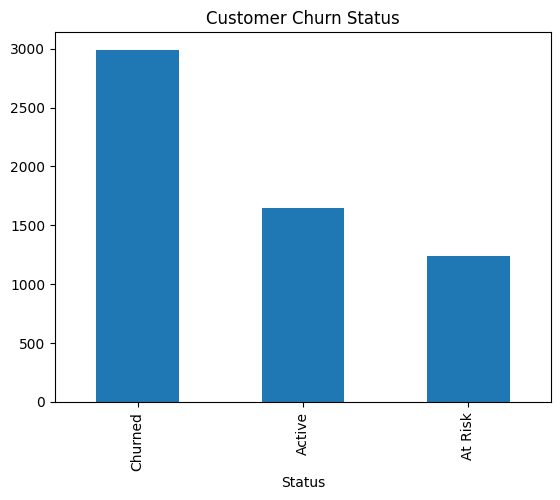

In [13]:
import matplotlib.pyplot as plt

plt.figure()
status_counts.plot(kind="bar")

plt.title("Customer Churn Status")

plt.savefig(
    "../outputs/figures/churn_status.png",
    bbox_inches="tight"
)

plt.show()

## Churn Analysis Insights

A significant portion of customers have not purchased recently,
indicating potential churn.

At-risk customers should be targeted with promotions.

Active customers should be retained using loyalty programs.

Reducing churn can significantly increase CLV.